In [1]:
# Config & imports

import os
import numpy as np
import pandas as pd

# Modeling
from xgboost import XGBClassifier
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold,
    cross_val_predict, cross_val_score
)

# Metrics & plots
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# I/O
DATA_PATH = "./data/train_mp.csv"
os.makedirs("./visual", exist_ok=True)

# Excluded feature columns
NON_FEATURE_COLS = {
    "material_id", "formula", "composition", "composition_obj",
    "formation_energy_per_atom", "band_gap"
}

# Class names for plots
CLASS_NAMES = ["C", "SC"]  # 0, 1


In [2]:
# Load data & define conductor/semiconductor classes

df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
X_all = df[feature_cols].select_dtypes(include=[np.number]).copy()

# Binary labels from band_gap
bg = pd.to_numeric(df["band_gap"], errors="coerce")
tol = 1e-8
y_all = pd.Series(np.nan, index=bg.index, dtype="float64")

y_all[(bg >= 0.1) & (bg <= 3.0)] = 1
y_all[np.abs(bg - 0.0) <= tol] = 0

mask_valid = y_all.notna()
dropped = (~mask_valid).sum()
print(f"Total rows: {len(df)} | Kept (classified): {mask_valid.sum()} | Dropped (outside spec): {dropped}")

X_all = X_all.loc[mask_valid].reset_index(drop=True)
y_all = y_all.loc[mask_valid].astype(int).reset_index(drop=True)

print("Class counts:", dict(zip(*np.unique(y_all, return_counts=True))))
print("n_features (numeric):", X_all.shape[1])
print("first 5 feature columns:", feature_cols[:5])


Total rows: 6419 | Kept (classified): 5584 | Dropped (outside spec): 835
Class counts: {np.int64(0): np.int64(3340), np.int64(1): np.int64(2244)}
n_features (numeric): 250
first 5 feature columns: ['H', 'He', 'Li', 'Be', 'B']


In [3]:
# Train/test split & imputation

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_all
)

# Median imputation
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))

print("train shape:", X_train.shape, "| test shape:", X_test.shape)
print("train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("test  class counts:", dict(zip(*np.unique(y_test, return_counts=True))))


train shape: (4467, 250) | test shape: (1117, 250)
train class counts: {np.int64(0): np.int64(2672), np.int64(1): np.int64(1795)}
test  class counts: {np.int64(0): np.int64(668), np.int64(1): np.int64(449)}


In [4]:
# XGBoost classifier + GridSearchCV

TREE_METHOD = "hist"  # or "gpu_hist" if CUDA GPU available

xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    tree_method=TREE_METHOD,
    use_label_encoder=False,
    eval_metric="logloss",
    n_jobs=1,
    scale_pos_weight=1.0,  # handle imbalance manually if needed
)

param_grid = {
    "n_estimators": [400, 800],
    "max_depth": [6, 10],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3],
    "gamma": [0.0, 0.2],
    "reg_lambda": [1.0, 5.0],
    "reg_alpha": [0.0, 0.5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gscv = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

gscv.fit(X_train, y_train)
best_clf = gscv.best_estimator_
print("best params:", gscv.best_params_)
print("best cv F1_macro:", gscv.best_score_)


Fitting 5 folds for each of 512 candidates, totalling 2560 fits


/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [09:56:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [09:56:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [09:56:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [09:56:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

best params: {'colsample_bytree': 1.0, 'gamma': 0.0, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 400, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'subsample': 0.8}
best cv F1_macro: 0.8595423024422827


In [5]:
# Evaluate model (train/test)

def summarize_classification(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    print(f"{label} Acc: {acc:.3f} | P: {p:.3f} | R: {r:.3f} | F1: {f1:.3f}")
    print("\nClassification report:\n",
          classification_report(y_true, y_pred,
                                target_names=CLASS_NAMES,
                                zero_division=0))
    return acc, p, r, f1

# Predictions
yhat_tr = best_clf.predict(X_train)
yhat_te = best_clf.predict(X_test)

print("== training ==")
tr_metrics = summarize_classification(y_train, yhat_tr, "Train")

print("\n== test ==")
te_metrics = summarize_classification(y_test, yhat_te, "Test")


== training ==
Train Acc: 0.963 | P: 0.961 | R: 0.962 | F1: 0.961

Classification report:
               precision    recall  f1-score   support

           C       0.97      0.97      0.97      2672
          SC       0.95      0.96      0.95      1795

    accuracy                           0.96      4467
   macro avg       0.96      0.96      0.96      4467
weighted avg       0.96      0.96      0.96      4467


== test ==
Test Acc: 0.863 | P: 0.857 | R: 0.858 | F1: 0.858

Classification report:
               precision    recall  f1-score   support

           C       0.89      0.88      0.89       668
          SC       0.83      0.84      0.83       449

    accuracy                           0.86      1117
   macro avg       0.86      0.86      0.86      1117
weighted avg       0.86      0.86      0.86      1117



In [6]:
# Cross-validation scores & predictions

cv_f1  = cross_val_score(best_clf, X_all, y_all, cv=cv, scoring="f1_macro", n_jobs=-1)
cv_acc = cross_val_score(best_clf, X_all, y_all, cv=cv, scoring="accuracy",  n_jobs=-1)

print(f"CV F1_macro: mean={cv_f1.mean():.3f} ± {cv_f1.std():.3f}")
print(f"CV Accuracy: mean={cv_acc.mean():.3f} ± {cv_acc.std():.3f}")

yhat_cv = cross_val_predict(best_clf, X_all, y_all, cv=cv, n_jobs=-1, method="predict")


/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [11:19:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [11:19:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [11:19:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [11:19:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

CV F1_macro: mean=0.858 ± 0.011
CV Accuracy: mean=0.863 ± 0.010


/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [11:19:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [11:19:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [11:19:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/adroit/miniconda3/envs/material/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [11:19:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

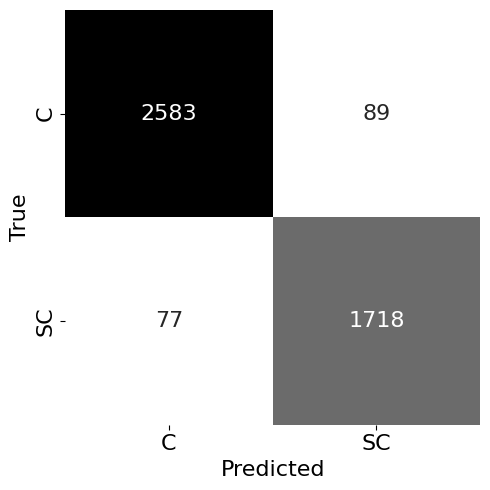

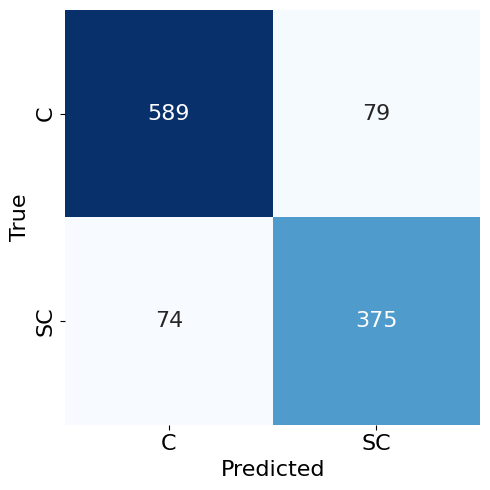

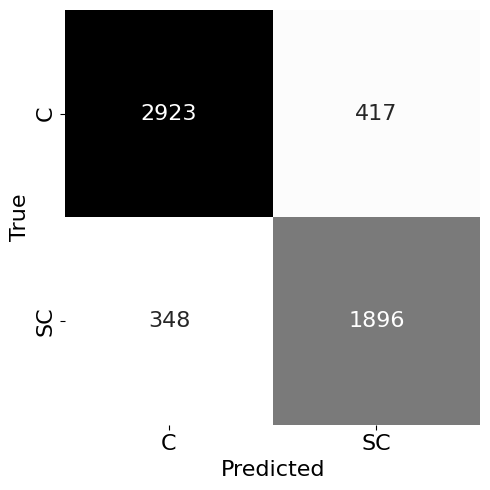

In [7]:
# Confusion matrices (train/test/CV)

def plot_cm(cm, cmap, title, filename):
    plt.figure(figsize=(5,5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        cbar=False, annot_kws={"size": 16}
    )
    plt.xlabel("Predicted", fontsize=16)
    plt.ylabel("True", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tight_layout()
    plt.savefig(filename, format="jpg", dpi=500, bbox_inches="tight")
    plt.show()

cm_train = confusion_matrix(y_train, yhat_tr, labels=[0,1])
cm_test  = confusion_matrix(y_test,  yhat_te, labels=[0,1])
cm_cv    = confusion_matrix(y_all,   yhat_cv, labels=[0,1])

plot_cm(cm_train, "Greys",  "Train", "./visual/fig_s2e.jpg")
plot_cm(cm_test,  "Blues",   "Test",  "./visual/fig3c.jpg")
plot_cm(cm_cv,    "Greys", "CV",    "./visual/fig_s2f.jpg")


/tmp/ipykernel_1232423/1023581261.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


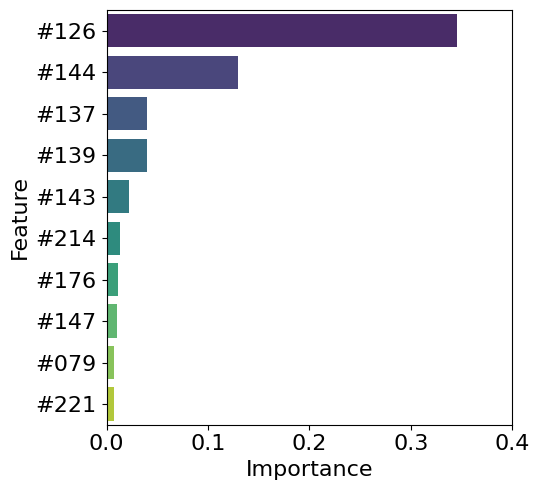

,Short name
MagpieData maximum MendeleevNumber,#126
MagpieData maximum Column,#144
MagpieData minimum MeltingT,#137
MagpieData range MeltingT,#139
MagpieData minimum Column,#143
MagpieData mode NdUnfilled,#214
MagpieData mean NpValence,#176
MagpieData avg_dev Column,#147
Au,#079
MagpieData minimum NUnfilled,#221


In [8]:
# Feature importance (gain-based)

importances = pd.Series(best_clf.feature_importances_, index=X_train.columns)
imp_top = importances.sort_values(ascending=False).head(10)

# Map original feature names → Feature #XXX
feature_map = {
    feat: f"#{str(X_train.columns.get_loc(feat)+1).zfill(3)}"
    for feat in imp_top.index
}
imp_top_short = imp_top.rename(index=feature_map)

plt.figure(figsize=(5.5,5))
sns.barplot(
    x=imp_top_short.values,
    y=imp_top_short.index,
    palette="viridis"
)
plt.xlabel("Importance", fontsize=16)
plt.ylabel("Feature", fontsize=16)

max_val = float(max(imp_top_short.max(), 0.15))
ticks = np.arange(0, max_val + 0.10, 0.10)
plt.xticks(ticks, fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig("./visual/fig3d.jpg", format="jpg", dpi=500, bbox_inches="tight")
plt.show()

lookup = pd.DataFrame.from_dict(feature_map, orient="index", columns=["Short name"])
display(lookup)


In [ ]:
# Predict on new data (optional)

# new_features_path = "/mnt/data/new_features.csv"
# out_path = "/mnt/data/pred_bandgap_class_xgb.csv"

# new_df = pd.read_csv(new_features_path)

# missing = set(X_train.columns) - set(new_df.columns)
# if missing:
#     raise ValueError(f"Missing required feature columns: {sorted(list(missing))[:10]} ...")

# X_new = new_df.reindex(columns=X_train.columns, fill_value=np.nan)
# X_new = X_new.fillna(X_train.median(numeric_only=True))

# pred_cls = best_clf.predict(X_new)
# pred_name = pd.Series(pred_cls).map({0:"conductor", 1:"semiconductor"})

# out = new_df.copy()
# out["predicted_class"] = pred_cls
# out["predicted_label"] = pred_name
# out.to_csv(out_path, index=False)
# print(f"Saved predictions to: {out_path}")
# out.head()
